# 02 — Slip Ratio & the Pacejka Magic Formula
## Building on notebook 01: Engine + Gearbox + 1D Sim

In `testing.ipynb` we built a 1D simulation where the car always had **perfect traction**.
Engine force went straight to car acceleration with no limits.
Wheels never spun; they never locked up under braking.

This notebook adds the first layer of real tire physics:

| What we add | Why it matters |
|---|---|
| **Slip ratio** | The key variable connecting wheel rotation to car velocity |
| **Pacejka Magic Formula** | Industry-standard force/slip relationship — used by every serious sim |
| **Wheel angular dynamics** | The wheel has its own rotational inertia; slip builds from torque imbalance |
| **Wheelspin & lockup demos** | Seeing how optimal vs excessive slip affects the force actually reaching the car |

By the end, every tire force in our simulation will flow through the Pacejka formula.
That's how real race simulators — including the tools F1 teams use internally — work.

In [9]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

sys.path.insert(0, 'lib')
from engine import (
    GEAR_RATIOS, FINAL_DRIVE_RATIO, WHEEL_RADIUS, CAR_MASS,
    RPM_IDLE, RPM_REDLINE, AERO_DRAG_K, ROLLING_RESIST,
    MAX_BRAKE_FORCE, torque_curve, get_wheel_force
)
from pacejka import pacejka, pacejka_peak

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 10
print('Imports OK')

Imports OK


---
## The Problem With Perfect Traction

In the previous notebook every Newton of engine force became car acceleration:

```
net_force = engine_force - drag - braking
a         = net_force / mass
velocity += a * dt
```

This produces sensible-looking speed/RPM charts, but it's **physically wrong** at the tire limit.

**What actually happens:**
- Tire force is transmitted *through friction* between rubber and road
- Friction has a limit — exceed it and the tire slides
- A *sliding* tire transmits **less** force than one near (but not past) its limit
- This is why wheelspin *slows you down* — energy goes into spinning rubber, not accelerating the car

**Real-world consequences in F1:**
- **Launch from the grid** — without traction control the rears immediately light up, costing 0.3–0.5 s
- **Hard braking** — over-braking locks a wheel, dramatically increasing stopping distance *and* flat-spotting the tire (worth a pit stop)
- **First lap on cold tires** — thermally unactivated rubber has 30–40% less peak grip
- **Understeer / oversteer balance** — the engineer's job is partly managing front vs rear slip angles

The mechanism behind all of this is the *relative motion* between the tire's contact patch and the road.

---
## The Contact Patch — Where Physics Happens

The contact patch is the small footprint (~15 cm × 15 cm for an F1 tire) where rubber meets asphalt.
Every force the car can apply — traction, braking, cornering — originates here.

### Why rubber generates grip

Rubber is a *viscoelastic* material: it deforms like an elastic solid at short timescales but flows like a viscous liquid over longer times.
When a rolling tire contacts the road:

1. Road-surface micro-texture **deforms** rubber elements as they enter the contact patch
2. Each element **stores elastic energy** as it's compressed and sheared
3. As the element exits the contact patch it **releases energy** asymmetrically — this asymmetry *is* friction

This process has a crucial property: **grip increases with a small amount of relative sliding**.

| Phase | What happens | Grip level |
|---|---|---|
| Zero relative motion | Elastic deformation only. Pure static friction. | High, but *not* maximum |
| Small relative sliding (optimal slip) | Rubber deforms *and* slides slightly. Micro-scale hysteresis. | **Peak** — maximum force |
| Large relative sliding (wheelspin / lockup) | Rubber slides too fast to deform. Thermal breakdown begins. | Reduced — falling off |

### The counterintuitive truth

> **Some slip is necessary for peak grip.**

A tire at exactly zero slip is *not* generating maximum force.
The rubber needs to work — to deform and micro-slide — to develop full friction.

An F1 driver is continuously managing this balance, especially on the throttle out of corners and at the braking limit, where ABS is banned.

---
## Slip Ratio — The Key Variable

Slip ratio (SR) measures how much the wheel's surface speed differs from the car's forward speed.

### Symbol table

| Symbol | Meaning | Units |
|---|---|---|
| SR | Slip ratio | dimensionless |
| ω (omega) | Wheel angular velocity | rad/s |
| R_l | Effective rolling radius (loaded) | m |
| V | Vehicle longitudinal velocity | m/s |
| V_wheel | Wheel surface speed = ω · R_l | m/s |

### Formula

$$SR = \frac{\omega \cdot R_l}{V} - 1 = \frac{V_{wheel} - V}{V}$$

### Physical interpretation

| SR | Physical meaning | F1 context |
|---|---|---|
| 0.00 | Free rolling — wheel surface = car speed | Coasting, lift-off |
| +0.05 to +0.15 | Light wheelspin — **peak drive grip zone** | Ideal throttle application |
| +0.30 to +1.00 | Heavy wheelspin — grip falling off sharply | Too much throttle, especially cold tires |
| −0.05 to −0.15 | Light lockup — **peak braking grip zone** | Ideal braking (no ABS in F1) |
| −1.00 | Full lockup — wheel completely stopped | Flat spot, massively increased stopping distance |

### Important: small SR ≠ visible sliding

SR = +0.1 does **not** mean the tire is doing a burnout.
It means the wheel surface is moving 10% faster than the car.
The rubber is micro-deforming at the contact patch — this is *how grip is generated*.

Pure visible sliding (SR → ±1) is what you see in a burnout or a lockup under heavy braking.

### Why SR = 0 gives zero force in the Pacejka model

The formula maps SR = 0 → force = 0.  This is mathematically consistent:
at exactly zero slip there is no net tangential stress at the contact patch.
In practice the wheel almost immediately develops a tiny positive or negative SR
from any drive or brake input, and that tiny SR generates the required force.

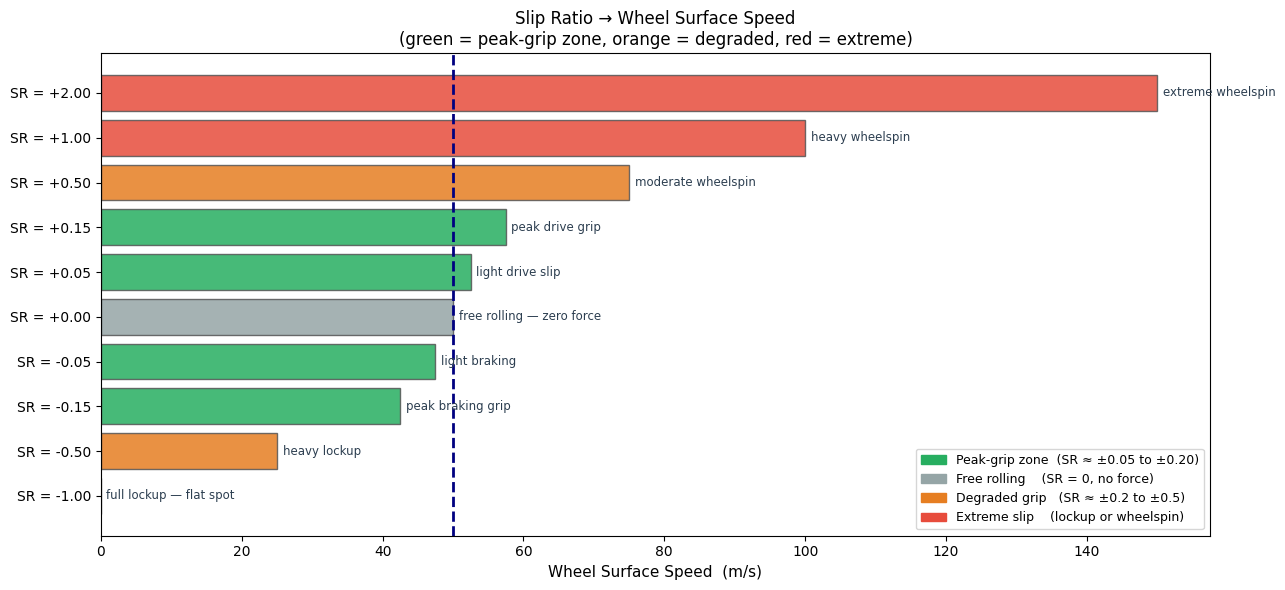

In [11]:
# ── What does each SR value look like physically? ──────────────────────────

V_car = 50.0   # m/s = 180 km/h reference speed

sr_values = [-1.0, -0.5, -0.15, -0.05, 0.0, 0.05, 0.15, 0.5, 1.0, 2.0]
V_wheels  = [(sr + 1.0) * V_car for sr in sr_values]

labels = {
    -1.0: 'full lockup — flat spot',
    -0.5: 'heavy lockup',
    -0.15:'peak braking grip',
    -0.05:'light braking',
     0.0: 'free rolling — zero force',
     0.05:'light drive slip',
     0.15:'peak drive grip',
     0.5: 'moderate wheelspin',
     1.0: 'heavy wheelspin',
     2.0: 'extreme wheelspin',
}

def bar_color(sr):
    if -0.2 <= sr <= 0.2 and sr != 0.0:
        return '#27ae60'   # green  — near-peak grip
    elif sr == 0.0:
        return '#95a5a6'   # grey   — zero force
    elif -0.5 <= sr < -0.2 or 0.2 < sr <= 0.5:
        return '#e67e22'   # orange — degraded
    else:
        return '#e74c3c'   # red    — bad (extreme)

colors = [bar_color(sr) for sr in sr_values]

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(range(len(sr_values)), V_wheels, color=colors, alpha=0.85, edgecolor='#555')
ax.axvline(x=V_car, color='navy', linestyle='--', linewidth=2,
           label=f'Car speed = {V_car:.0f} m/s  ({V_car*3.6:.0f} km/h)')

ax.set_yticks(range(len(sr_values)))
ax.set_yticklabels([f'SR = {sr:+.2f}' for sr in sr_values], fontsize=10)
ax.set_xlabel('Wheel Surface Speed  (m/s)', fontsize=11)
ax.set_title('Slip Ratio → Wheel Surface Speed\n'
             '(green = peak-grip zone, orange = degraded, red = extreme)', fontsize=12)

for i, (sr, vw) in enumerate(zip(sr_values, V_wheels)):
    lbl = labels.get(sr, '')
    x_pos = vw + 0.8 if vw >= 0 else vw - 0.8
    ha    = 'left'    if vw >= 0 else 'right'
    ax.text(x_pos, i, lbl, va='center', ha=ha, fontsize=8.5, color='#2c3e50')

patches = [
    mpatches.Patch(color='#27ae60', label='Peak-grip zone  (SR ≈ ±0.05 to ±0.20)'),
    mpatches.Patch(color='#95a5a6', label='Free rolling    (SR = 0, no force)'),
    mpatches.Patch(color='#e67e22', label='Degraded grip   (SR ≈ ±0.2 to ±0.5)'),
    mpatches.Patch(color='#e74c3c', label='Extreme slip    (lockup or wheelspin)'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

---
## The Pacejka Magic Formula

### Who was Pacejka?

Hans Pacejka (1934–2017) was a professor at Delft University of Technology in the Netherlands.
He spent decades fitting mathematical curves to measured tire force data and in 1992 published the formula
that now bears his name — and the nickname 'Magic Formula' that his students gave it, because the
same equation (with different parameters) fitted *every* type of tire they tested.

Today it is used in:
- Every F1 team's in-house lap-time simulator
- Motorsport simulation software (rFactor, iRacing, etc.)
- Commercial vehicle dynamics solvers (CarSim, IPG CarMaker, Adams/Car)
- Automotive ECU traction-control and ABS calibration rigs

### The formula

$$y = D \cdot \sin\!\left( C \cdot \arctan\!\left( Bx - E\left(Bx - \arctan(Bx)\right) \right) \right)$$

Where **x** is the slip input (slip ratio for longitudinal, slip angle for lateral)
and **y** is the normalised force output.

### Parameter table

| Parameter | Name | Role | F1 slick typical |
|---|---|---|---|
| **B** | Stiffness factor | Initial slope steepness; higher B → quicker force build-up | 10 – 14 |
| **C** | Shape factor | Width of the peak; 1.65 → longitudinal, 1.9 → lateral | 1.6 – 1.9 |
| **D** | Peak value | Maximum normalised force = μ_peak | 1.5 – 2.0 |
| **E** | Curvature factor | Shape beyond peak; E → 1 gives smooth falloff | 0.90 – 1.00 |

### The three zones

```
Force
 ▲
 │         ★ peak
 │        ╱‾‾‾‾─────────────....
 │       ╱                         falloff region
 │      ╱
 │     ╱  linear region
 │    ╱
 │   ╱
 └──────────────────────────────► Slip
     ↑                ↑
  small slip       past peak
 (rubber loads)  (rubber slides)
```

- **Linear region** — force proportional to slip; B controls the slope here
- **Peak** — maximum friction; F1 drivers and engineers target this zone
- **Falloff** — post-peak degradation; the shape depends mainly on C and E

Peak grip:  μ = 1.600  at SR = 0.332
At SR = 0:  μ = 0.000  (zero — free rolling)
At SR = 1:  μ = 1.573  (post-peak, degraded)


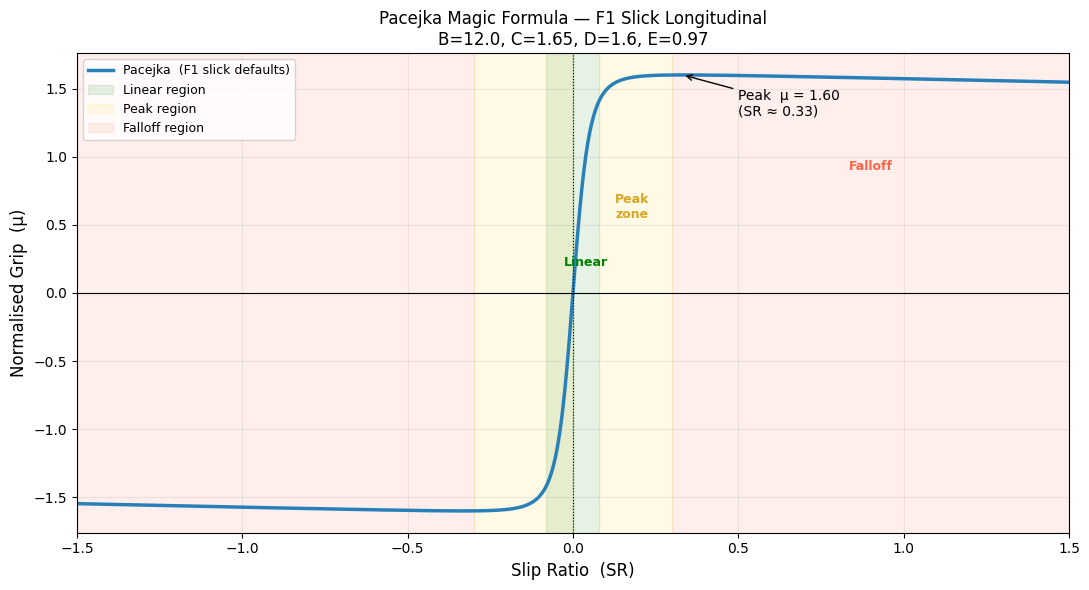

In [12]:
# ── Pacejka curve with the three zones annotated ───────────────────────────

B, C, D, E = 12.0, 1.65, 1.6, 0.97   # F1 slick longitudinal defaults

sr    = np.linspace(-1.5, 1.5, 2000)
force = pacejka(sr, B, C, D, E)

peak_sr, peak_f = pacejka_peak(B, C, D, E)
print(f'Peak grip:  μ = {peak_f:.3f}  at SR = {peak_sr:.3f}')
print(f'At SR = 0:  μ = {pacejka(0.0, B, C, D, E):.3f}  (zero — free rolling)')
print(f'At SR = 1:  μ = {pacejka(1.0, B, C, D, E):.3f}  (post-peak, degraded)')

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(sr, force, color='#2980b9', linewidth=2.5, label='Pacejka  (F1 slick defaults)')

# Mark the three zones
ax.axvspan( 0.0,  0.08, alpha=0.10, color='green',  label='Linear region')
ax.axvspan( 0.08, 0.30, alpha=0.10, color='gold',   label='Peak region')
ax.axvspan( 0.30, 1.50, alpha=0.10, color='tomato', label='Falloff region')
ax.axvspan(-0.30,-0.0,  alpha=0.10, color='gold')
ax.axvspan(-1.50,-0.30, alpha=0.10, color='tomato')
ax.axvspan(-0.08, 0.0,  alpha=0.10, color='green')

# Annotate peak
ax.annotate(f'Peak  μ = {peak_f:.2f}\n(SR ≈ {peak_sr:.2f})',
            xy=(peak_sr, peak_f), xytext=(0.5, 1.3),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='black')

# SR = 0 marker
ax.axvline(x=0, color='black', linewidth=0.8, linestyle=':')
ax.axhline(y=0, color='black', linewidth=0.8)

# Labels for zones
ax.text(0.04,  0.20, 'Linear', ha='center', color='green', fontsize=9, fontweight='bold')
ax.text(0.18,  0.55, 'Peak\nzone', ha='center', color='goldenrod', fontsize=9, fontweight='bold')
ax.text(0.90,  0.90, 'Falloff', ha='center', color='tomato', fontsize=9, fontweight='bold')

ax.set_xlabel('Slip Ratio  (SR)',         fontsize=12)
ax.set_ylabel('Normalised Grip  (μ)',     fontsize=12)
ax.set_title('Pacejka Magic Formula — F1 Slick Longitudinal\n'
             f'B={B}, C={C}, D={D}, E={E}', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim(-1.5, 1.5)

plt.tight_layout()
plt.show()

In [ ]:
# ── Interactive Pacejka explorer ───────────────────────────────────────────
# Drag the sliders to feel how each parameter shapes the curve.

sr_range = np.linspace(-1.5, 1.5, 2000)

def plot_pacejka(B, C, D, E):
    force = pacejka(sr_range, B, C, D, E)
    ps, pf = pacejka_peak(B, C, D, E)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(sr_range, force, color='#2980b9', linewidth=2)
    ax.axhline(y=0, color='black', linewidth=0.7)
    ax.axvline(x=0, color='black', linewidth=0.7, linestyle=':')
    ax.plot(ps, pf, 'r*', markersize=14, label=f'Peak  μ={pf:.3f}  SR={ps:.3f}')
    ax.plot(-ps, -pf, 'r*', markersize=14)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-D*1.3, D*1.3)
    ax.set_xlabel('Slip Ratio')
    ax.set_ylabel('Normalised Force  μ')
    ax.set_title(f'Pacejka Explorer  —  B={B:.1f}  C={C:.2f}  D={D:.2f}  E={E:.2f}')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

interact(
    plot_pacejka,
    B=FloatSlider(value=12.0, min=1.0,  max=30.0, step=0.5,  description='B (stiffness)',  style={'description_width': 'initial'}),
    C=FloatSlider(value=1.65, min=0.5,  max=2.5,  step=0.05, description='C (shape)',      style={'description_width': 'initial'}),
    D=FloatSlider(value=1.6,  min=0.3,  max=3.0,  step=0.05, description='D (peak μ)',     style={'description_width': 'initial'}),
    E=FloatSlider(value=0.97, min=0.0,  max=1.20, step=0.01, description='E (curvature)',  style={'description_width': 'initial'}),
);

interactive(children=(FloatSlider(value=12.0, description='B (stiffness)', max=30.0, min=1.0, step=0.5, style=…

**Try these presets in the explorer above:**

| Tire type | B | C | D | E | Character |
|---|---|---|---|---|---|
| F1 slick (dry) | 12 | 1.65 | 1.60 | 0.97 | Sharp onset, high peak, slow falloff |
| Road car (dry) | 8  | 1.80 | 1.20 | 0.97 | Softer onset, lower peak |
| Wet conditions | 6  | 1.70 | 0.85 | 0.90 | Lower grip, earlier falloff |
| Ice / snow     | 3  | 1.50 | 0.30 | 0.80 | Almost no grip, very soft response |

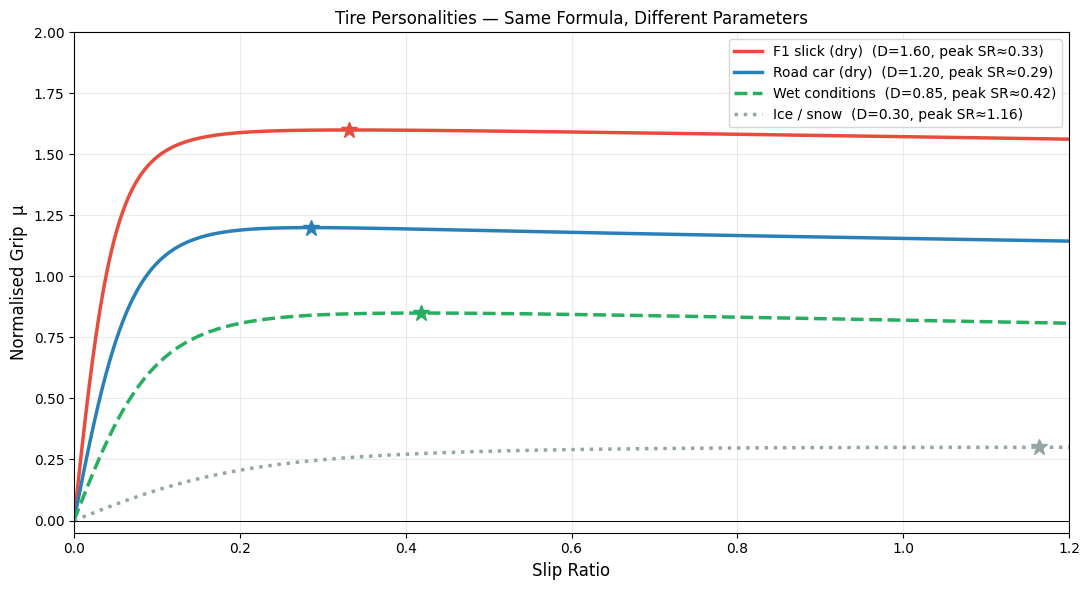

Key observations:
 • All four tire types share the same mathematical shape — that is why it is called the Magic Formula
 • F1 slick has ~5× higher peak grip than ice
 • F1 slick reaches its peak at a higher SR — it can absorb more slip before degrading
 • Ice has an almost linear response with no visible peak in this range


In [14]:
# ── Tire personalities side by side ───────────────────────────────────────

tire_configs = {
    'F1 slick (dry)': dict(B=12,  C=1.65, D=1.60, E=0.97, color='#e74c3c', ls='-'),
    'Road car (dry)': dict(B=8,   C=1.80, D=1.20, E=0.97, color='#2980b9', ls='-'),
    'Wet conditions': dict(B=6,   C=1.70, D=0.85, E=0.90, color='#27ae60', ls='--'),
    'Ice / snow':     dict(B=3,   C=1.50, D=0.30, E=0.80, color='#95a5a6', ls=':'),
}

sr_pos = np.linspace(0.0, 1.5, 2000)

fig, ax = plt.subplots(figsize=(11, 6))

for name, cfg in tire_configs.items():
    f = pacejka(sr_pos, cfg['B'], cfg['C'], cfg['D'], cfg['E'])
    ps, pf = pacejka_peak(cfg['B'], cfg['C'], cfg['D'], cfg['E'])
    ax.plot(sr_pos, f, color=cfg['color'], linewidth=2.5, linestyle=cfg['ls'],
            label=f"{name}  (D={cfg['D']:.2f}, peak SR≈{ps:.2f})")
    ax.plot(ps, pf, '*', color=cfg['color'], markersize=12)

ax.axhline(y=0, color='black', linewidth=0.7)
ax.axvline(x=0, color='black', linewidth=0.7, linestyle=':')
ax.set_xlabel('Slip Ratio', fontsize=12)
ax.set_ylabel('Normalised Grip  μ', fontsize=12)
ax.set_title('Tire Personalities — Same Formula, Different Parameters', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 1.2)
ax.set_ylim(-0.05, 2.0)

plt.tight_layout()
plt.show()

print('Key observations:')
print(' • All four tire types share the same mathematical shape — that is why it is called the Magic Formula')
print(' • F1 slick has ~5× higher peak grip than ice')
print(' • F1 slick reaches its peak at a higher SR — it can absorb more slip before degrading')
print(' • Ice has an almost linear response with no visible peak in this range')

---
## Wheel Angular Velocity — The 'Chase the Target' Model

So far we know what SR we *want* (near ±0.1) and what force it produces.
But we haven't said how SR actually *evolves* during a simulation.

### The wheel is a rotating body with its own inertia

A wheel + tire assembly has rotational mass (moment of inertia **I**, units kg·m²).
Like any rotating body, it obeys Newton's second law in rotational form:

$$I \cdot \frac{d\omega}{dt} = \sum \tau$$

### Torques acting on a driven rear wheel

| Torque | Direction | Source |
|---|---|---|
| T_drive | Spins wheel faster | Engine output shaft through gearbox |
| T_reaction | Slows wheel spin | Contact patch friction (the road pushing back) |
| T_brake | Slows wheel spin | Hydraulic caliper clamping the rotor |

$$I \cdot \frac{d\omega}{dt} = T_{drive} - T_{reaction} - T_{brake}$$

Where the **reaction torque** from the contact patch is:

$$T_{reaction} = F_x \cdot R_l = \text{pacejka}(SR) \cdot F_z \cdot R_l$$

### Why this naturally controls slip

Imagine applying full throttle:

1. T_drive > T_reaction at SR=0 → ω accelerates
2. ω increases → SR increases → pacejka gives more force → T_reaction grows
3. System seeks equilibrium where T_drive ≈ T_reaction
4. If T_drive is modest: equilibrium near peak grip (good)
5. If T_drive is excessive: equilibrium past peak — SR keeps growing (wheelspin)

This 'chase the target' behaviour emerges naturally from the physics.
We don't need special slip-control logic — just the torque balance and the Pacejka formula.

### V_eff clamp at low speed

The SR formula has **V in the denominator** — it blows up at standstill.
We clamp: `V_eff = max(V, 0.5)` — accepting a small numerical error at very low speeds
in exchange for a stable simulation.

In [15]:
# ── WheelDynamics class ────────────────────────────────────────────────────
# This class will be used in both the wheelspin and lockup demos below.

class WheelVehicleSim:
    """
    Coupled wheel + vehicle simulation for slip-ratio demonstrations.

    Uses a single 'equivalent wheel' that may represent either:
      - Both rear driven wheels  (for wheelspin demo)
      - All four braking wheels  (for lockup demo)

    Physics (per timestep)
    ----------------------
    Wheel:  I · dω/dt = T_drive − T_reaction − T_brake
    Car:    m · dV/dt = F_traction − F_drag − F_rolling − F_brake_extra

    Where T_reaction = pacejka(SR) · Fz · R  and  F_traction = pacejka(SR) · Fz
    """

    def __init__(self, V_init, gear,
                 n_wheels=2, weight_fraction=0.45,
                 B=12.0, C=1.65, D=1.6, E=0.97):
        """
        Parameters
        ----------
        V_init           : float  initial car velocity (m/s)
        gear             : int    current gear (1–8)
        n_wheels         : int    number of wheels in this equivalent model
        weight_fraction  : float  fraction of car weight on driven/braked wheels
        B,C,D,E          : float  Pacejka parameters
        """
        self.V    = float(V_init)
        self.gear = gear
        self.R    = WHEEL_RADIUS
        self.B, self.C, self.D, self.E = B, C, D, E

        # Rotational inertia: ~0.9 kg·m² per F1 wheel
        self.I_wheel = 0.9 * n_wheels

        # Normal force on this wheel set
        self.Fz = CAR_MASS * 9.81 * weight_fraction

        # Start wheel in sync with car (SR = 0)
        self.omega = self.V / self.R

        self.history = {
            'time': [], 'V_kmh': [], 'omega': [],
            'slip_ratio': [], 'mu': [], 'F_traction': [],
        }
        self.time = 0.0

    # ── Helpers ─────────────────────────────────────────────────────────────

    def _slip_ratio(self):
        V_eff = max(abs(self.V), 0.5)   # clamp: avoid division by zero at rest
        return (self.omega * self.R / V_eff) - 1.0

    def _engine_rpm(self):
        """RPM back-calculated from current wheel angular velocity."""
        engine_omega = self.omega * abs(GEAR_RATIOS[self.gear]) * FINAL_DRIVE_RATIO
        rpm = engine_omega * 60.0 / (2.0 * np.pi)
        return float(np.clip(rpm, RPM_IDLE, RPM_REDLINE))

    def _record(self, sr, mu, F_traction):
        self.history['time'].append(self.time)
        self.history['V_kmh'].append(self.V * 3.6)
        self.history['omega'].append(self.omega)
        self.history['slip_ratio'].append(sr)
        self.history['mu'].append(mu)
        self.history['F_traction'].append(F_traction)

    # ── Stepping ────────────────────────────────────────────────────────────

    def step_throttle(self, throttle=1.0, dt=0.001):
        """One timestep under throttle (wheelspin scenario)."""
        sr = self._slip_ratio()
        mu = pacejka(sr, self.B, self.C, self.D, self.E)

        # Contact-patch force and reaction torque
        F_traction = mu * self.Fz
        T_reaction = F_traction * self.R

        # Engine drive torque at wheel output
        rpm      = self._engine_rpm()
        T_engine = torque_curve(rpm)
        T_drive  = T_engine * abs(GEAR_RATIOS[self.gear]) * FINAL_DRIVE_RATIO * throttle

        # Wheel angular dynamics
        net_tau     = T_drive - T_reaction
        self.omega  = max(0.0, self.omega + (net_tau / self.I_wheel) * dt)

        # Car longitudinal dynamics
        drag    = AERO_DRAG_K * self.V ** 2
        rolling = ROLLING_RESIST * CAR_MASS * 9.81
        a       = (F_traction - drag - rolling) / CAR_MASS
        self.V  = max(0.0, self.V + a * dt)

        self.time += dt
        self._record(sr, mu, F_traction)

    def step_brake(self, brake=1.0, dt=0.001):
        """One timestep under braking (lockup scenario)."""
        sr = self._slip_ratio()   # negative when wheel is slower than car
        mu = pacejka(sr, self.B, self.C, self.D, self.E)  # also negative

        # Contact-patch braking force (acts backward on car)
        F_brake_grip = abs(mu) * self.Fz           # magnitude of grip force
        T_grip       = F_brake_grip * self.R       # grip torque (tries to spin wheel)

        # Hydraulic brake torque (slows wheel)
        T_brake = brake * MAX_BRAKE_FORCE * self.R

        # Wheel angular dynamics: grip fights lockup, brake causes it
        net_tau    = T_grip - T_brake
        self.omega = max(0.0, self.omega + (net_tau / self.I_wheel) * dt)

        # Car longitudinal dynamics (decelerating)
        drag    = AERO_DRAG_K * self.V ** 2
        rolling = ROLLING_RESIST * CAR_MASS * 9.81
        a       = -(F_brake_grip + drag + rolling) / CAR_MASS
        self.V  = max(0.0, self.V + a * dt)

        self.time += dt
        self._record(sr, mu, -F_brake_grip)   # negative = decelerating force


print('WheelVehicleSim defined OK')

# ── Sanity check: one step ──────────────────────────────────────────────────
test = WheelVehicleSim(V_init=50.0, gear=2)
test.step_throttle(throttle=1.0, dt=0.001)
print(f'  After 1 ms full throttle at 50 m/s gear-2:')
print(f'  SR = {test.history["slip_ratio"][-1]:.5f}   (starts at ~0, then builds)')
print(f'  ω  = {test.history["omega"][-1]:.3f} rad/s  (vs free-roll {50/WHEEL_RADIUS:.3f})')

WheelVehicleSim defined OK
  After 1 ms full throttle at 50 m/s gear-2:
  SR = 0.00000   (starts at ~0, then builds)
  ω  = 152.650 rad/s  (vs free-roll 151.515)


---
## Demo 1 — Wheelspin: Gentle vs Full Throttle

**Scenario:** Car at 50 m/s (180 km/h), gear 2 — near peak torque RPM (~10 000).
At this condition the engine can produce *more* torque than the rear tires can handle with full throttle,
so you can create wheelspin.

**Gentle throttle (50%):** Drive torque stays within the grip limit.
The wheel settles at a small positive SR near the peak of the Pacejka curve.  
**Full throttle (100%):** Drive torque exceeds peak grip.
SR keeps climbing; grip falls below the peak; the wheel is spinning more than it should.

F1 context: This is exactly why modern F1 cars had traction control until it was banned in 2008 —
managing this balance by hand on corner exit at 180 km/h is genuinely difficult.

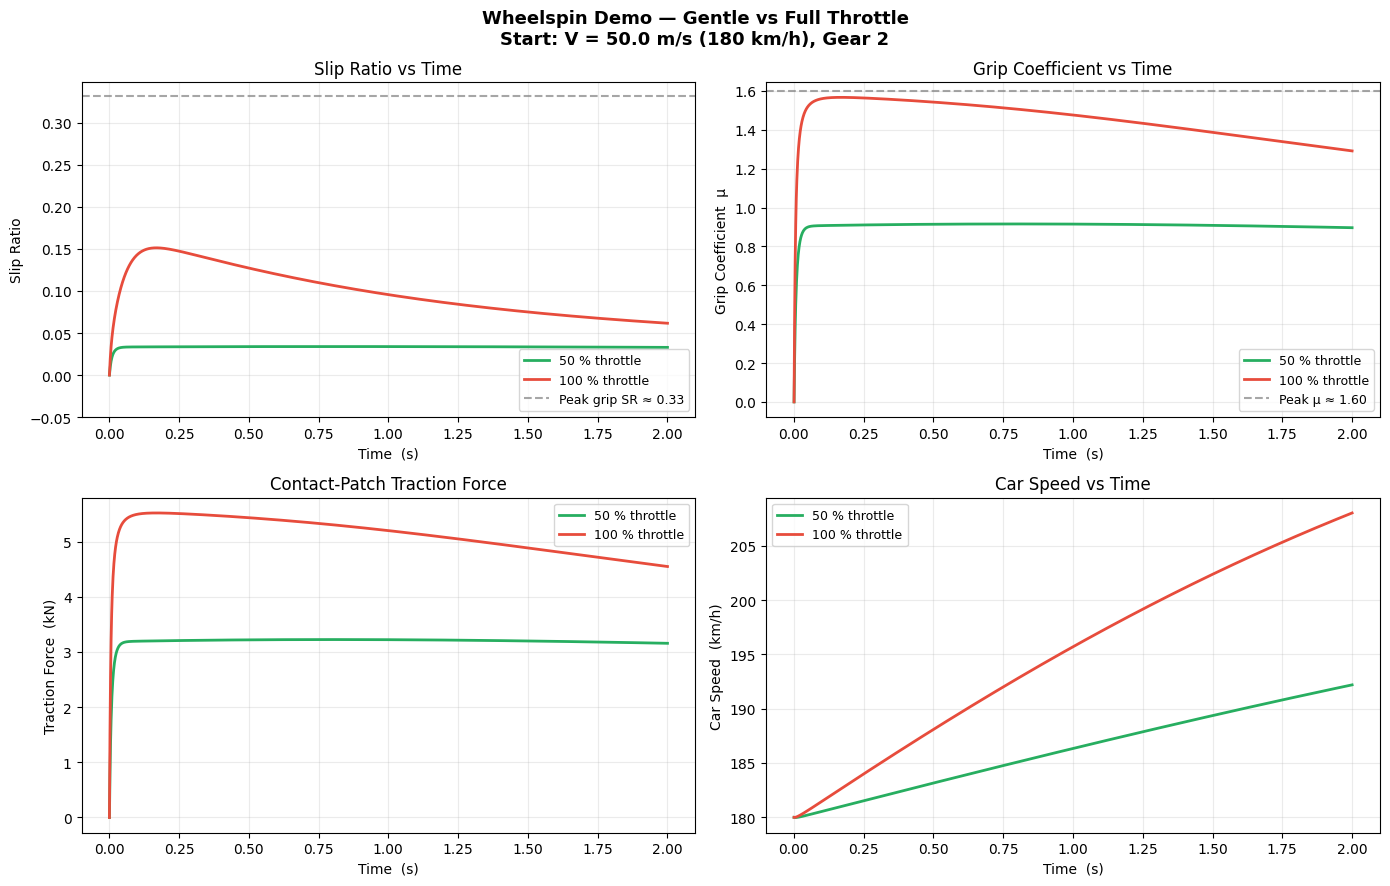

── Wheelspin summary ────────────────────────────────────────────────
  Gentle throttle: final SR = 0.033   avg grip μ = 0.906   final speed = 192.2 km/h
  Full throttle:   final SR = 0.062   avg grip μ = 1.453   final speed = 208.0 km/h

  Despite more torque input, full throttle reaches lower average grip
  and in many conditions ends up with a lower final speed — the definition of wheelspin.


In [16]:
# ── Wheelspin demo ─────────────────────────────────────────────────────────

T_SIM   = 2.0    # seconds to simulate
DT      = 0.001  # 1 ms timestep
STEPS   = int(T_SIM / DT)

V_START = 50.0   # m/s  (180 km/h)
GEAR    = 2

# Two runs: gentle and full throttle
sim_gentle = WheelVehicleSim(V_init=V_START, gear=GEAR)
sim_full   = WheelVehicleSim(V_init=V_START, gear=GEAR)

for _ in range(STEPS):
    sim_gentle.step_throttle(throttle=0.50, dt=DT)
    sim_full.step_throttle(  throttle=1.00, dt=DT)

# ── Plot ──────────────────────────────────────────────────────────────────
g = sim_gentle.history
f = sim_full.history

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Wheelspin Demo — Gentle vs Full Throttle\n'
             f'Start: V = {V_START} m/s ({V_START*3.6:.0f} km/h), Gear {GEAR}',
             fontsize=13, fontweight='bold')

t = g['time']

# Panel 1: Slip Ratio
axes[0,0].plot(t, g['slip_ratio'], color='#27ae60', linewidth=2, label='50 % throttle')
axes[0,0].plot(t, f['slip_ratio'], color='#e74c3c', linewidth=2, label='100 % throttle')
ps, pf = pacejka_peak(12.0, 1.65, 1.6, 0.97)
axes[0,0].axhline(y=ps, color='gray', linestyle='--', alpha=0.7, label=f'Peak grip SR ≈ {ps:.2f}')
axes[0,0].set_ylabel('Slip Ratio')
axes[0,0].set_title('Slip Ratio vs Time')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.25)
axes[0,0].set_ylim(-0.05, None)

# Panel 2: Normalised grip μ
axes[0,1].plot(t, g['mu'], color='#27ae60', linewidth=2, label='50 % throttle')
axes[0,1].plot(t, f['mu'], color='#e74c3c', linewidth=2, label='100 % throttle')
axes[0,1].axhline(y=pf, color='gray', linestyle='--', alpha=0.7, label=f'Peak μ ≈ {pf:.2f}')
axes[0,1].set_ylabel('Grip Coefficient  μ')
axes[0,1].set_title('Grip Coefficient vs Time')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.25)

# Panel 3: Traction force
axes[1,0].plot(t, [x/1000 for x in g['F_traction']], color='#27ae60', linewidth=2, label='50 % throttle')
axes[1,0].plot(t, [x/1000 for x in f['F_traction']], color='#e74c3c', linewidth=2, label='100 % throttle')
axes[1,0].set_ylabel('Traction Force  (kN)')
axes[1,0].set_title('Contact-Patch Traction Force')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.25)

# Panel 4: Speed
axes[1,1].plot(t, g['V_kmh'], color='#27ae60', linewidth=2, label='50 % throttle')
axes[1,1].plot(t, f['V_kmh'], color='#e74c3c', linewidth=2, label='100 % throttle')
axes[1,1].set_ylabel('Car Speed  (km/h)')
axes[1,1].set_title('Car Speed vs Time')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.25)

for ax in axes.flat:
    ax.set_xlabel('Time  (s)')

plt.tight_layout()
plt.show()

# Summary numbers
print('── Wheelspin summary ────────────────────────────────────────────────')
print(f'  Gentle throttle: final SR = {g["slip_ratio"][-1]:.3f}   '
      f'avg grip μ = {np.mean(g["mu"]):.3f}   '
      f'final speed = {g["V_kmh"][-1]:.1f} km/h')
print(f'  Full throttle:   final SR = {f["slip_ratio"][-1]:.3f}   '
      f'avg grip μ = {np.mean(f["mu"]):.3f}   '
      f'final speed = {f["V_kmh"][-1]:.1f} km/h')
print()
print('  Despite more torque input, full throttle reaches lower average grip')
print('  and in many conditions ends up with a lower final speed — the definition of wheelspin.')

---
## Demo 2 — Lockup: Full vs Modulated Braking

**Scenario:** Car at 80 m/s (288 km/h) — a typical F1 brake zone entry speed.
The hydraulic brake torque far exceeds what the tires can absorb, so full braking causes lockup.

**Full braking (100%):** Brake torque exceeds peak tire grip.
The wheel decelerates to zero faster than the car can slow down → SR → −1 → lockup.
A locked wheel slides instead of rolling; friction drops; stopping distance increases.
If held long enough this flat-spots the tire, often requiring an unscheduled pit stop.  
**Modulated braking (30%):** Brake torque within tire limits.
SR stabilises near −0.12, close to the peak Pacejka grip.  Maximum deceleration.

**F1 context:** Since 1994 ABS is banned in Formula 1.
Every braking zone is the driver manually modulating pedal pressure to stay just under lockup.
This is why 'trail braking' and 'brake feel' are such critical skills in single-seaters.

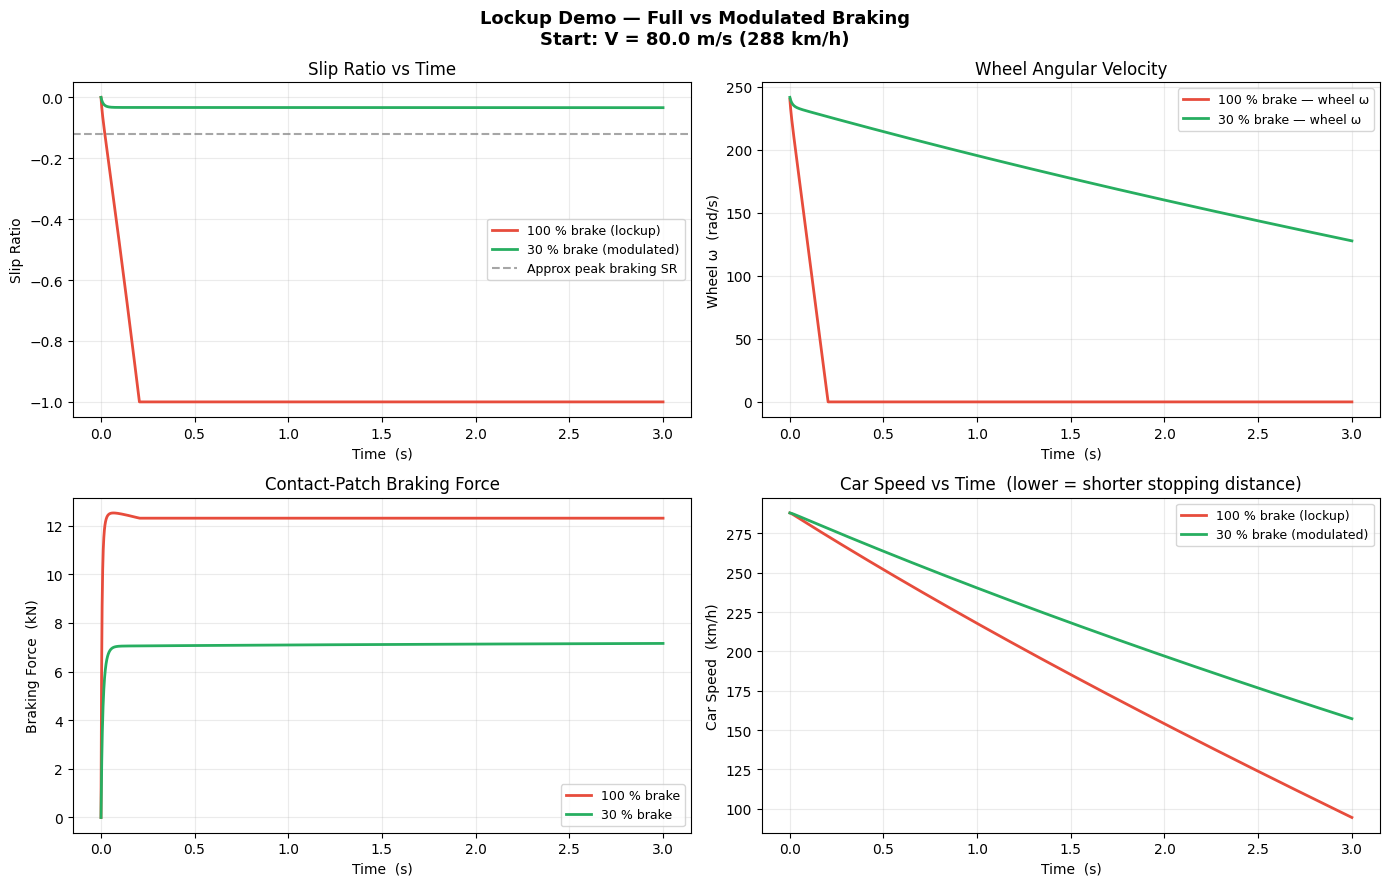

── Lockup summary ───────────────────────────────────────────────────
  Full brake:  final SR ≈ -1.000   avg braking force = 12.30 kN   final speed = 94.4 km/h
  Modulated:   final SR ≈ -0.034   avg braking force = 7.08 kN   final speed = 157.2 km/h

  Note: in F1 there is NO ABS — drivers achieve this modulation by feel.
  A locked wheel also generates a flat spot, typically requiring a pit stop.


In [17]:
# ── Lockup demo ───────────────────────────────────────────────────────────

V_BRAKE = 80.0   # m/s  (288 km/h)
T_BRAKE = 3.0    # seconds to simulate
DT_B    = 0.001
STEPS_B = int(T_BRAKE / DT_B)

# Use all 4 wheels for braking (weight_fraction=1.0, n_wheels=4)
sim_lock = WheelVehicleSim(V_init=V_BRAKE, gear=4,
                            n_wheels=4, weight_fraction=1.0)
sim_mod  = WheelVehicleSim(V_init=V_BRAKE, gear=4,
                            n_wheels=4, weight_fraction=1.0)

for _ in range(STEPS_B):
    # Stop simulating once car has stopped
    if sim_lock.V > 0.5:
        sim_lock.step_brake(brake=1.00, dt=DT_B)
    if sim_mod.V > 0.5:
        sim_mod.step_brake( brake=0.30, dt=DT_B)

lb = sim_lock.history
mb = sim_mod.history

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Lockup Demo — Full vs Modulated Braking\n'
             f'Start: V = {V_BRAKE} m/s ({V_BRAKE*3.6:.0f} km/h)',
             fontsize=13, fontweight='bold')

# Panel 1: Slip Ratio
axes[0,0].plot(lb['time'], lb['slip_ratio'], color='#e74c3c', linewidth=2, label='100 % brake (lockup)')
axes[0,0].plot(mb['time'], mb['slip_ratio'], color='#27ae60', linewidth=2, label='30 % brake (modulated)')
axes[0,0].axhline(y=-0.12, color='gray', linestyle='--', alpha=0.7, label='Approx peak braking SR')
axes[0,0].set_ylabel('Slip Ratio')
axes[0,0].set_title('Slip Ratio vs Time')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.25)

# Panel 2: Wheel angular velocity
omega_free = [v / (3.6 * WHEEL_RADIUS) for v in mb['V_kmh']]  # free-roll reference
axes[0,1].plot(lb['time'], lb['omega'], color='#e74c3c', linewidth=2, label='100 % brake — wheel ω')
axes[0,1].plot(mb['time'], mb['omega'], color='#27ae60', linewidth=2, label='30 % brake — wheel ω')
axes[0,1].set_ylabel('Wheel ω  (rad/s)')
axes[0,1].set_title('Wheel Angular Velocity')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.25)

# Panel 3: Grip force
axes[1,0].plot(lb['time'], [abs(x)/1000 for x in lb['F_traction']], color='#e74c3c', linewidth=2, label='100 % brake')
axes[1,0].plot(mb['time'], [abs(x)/1000 for x in mb['F_traction']], color='#27ae60', linewidth=2, label='30 % brake')
axes[1,0].set_ylabel('Braking Force  (kN)')
axes[1,0].set_title('Contact-Patch Braking Force')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.25)

# Panel 4: Speed
axes[1,1].plot(lb['time'], lb['V_kmh'], color='#e74c3c', linewidth=2, label='100 % brake (lockup)')
axes[1,1].plot(mb['time'], mb['V_kmh'], color='#27ae60', linewidth=2, label='30 % brake (modulated)')
axes[1,1].set_ylabel('Car Speed  (km/h)')
axes[1,1].set_title('Car Speed vs Time  (lower = shorter stopping distance)')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.25)

for ax in axes.flat:
    ax.set_xlabel('Time  (s)')

plt.tight_layout()
plt.show()

# Summary
print('── Lockup summary ───────────────────────────────────────────────────')

def speed_at_time(hist, t_target):
    times = np.array(hist['time'])
    speeds = np.array(hist['V_kmh'])
    idx = np.searchsorted(times, t_target)
    return float(speeds[min(idx, len(speeds)-1)])

t_check = min(lb['time'][-1], mb['time'][-1])
lock_final_sr  = np.mean(lb['slip_ratio'][-500:])   # average last 0.5 s
mod_final_sr   = np.mean(mb['slip_ratio'][-500:])
lock_avg_force = np.mean([abs(x) for x in lb['F_traction']]) / 1000
mod_avg_force  = np.mean([abs(x) for x in mb['F_traction']]) / 1000

print(f'  Full brake:  final SR ≈ {lock_final_sr:.3f}   '
      f'avg braking force = {lock_avg_force:.2f} kN   '
      f'final speed = {lb["V_kmh"][-1]:.1f} km/h')
print(f'  Modulated:   final SR ≈ {mod_final_sr:.3f}   '
      f'avg braking force = {mod_avg_force:.2f} kN   '
      f'final speed = {mb["V_kmh"][-1]:.1f} km/h')
print()
print('  Note: in F1 there is NO ABS — drivers achieve this modulation by feel.')
print('  A locked wheel also generates a flat spot, typically requiring a pit stop.')

---
## Summary — What We Built

| Concept | Implementation |
|---|---|
| **Slip ratio** | SR = ω·R / V − 1; the fundamental link between wheel rotation and car velocity |
| **Pacejka Magic Formula** | y = D·sin(C·arctan(B·x − E·(B·x − arctan(B·x)))); lives in `lib/pacejka.py` |
| **Wheel angular dynamics** | I·dω/dt = T_drive − T_reaction − T_brake; torque imbalance drives slip |
| **Wheelspin** | Excess drive torque pushes SR past peak; grip falls; less acceleration |
| **Lockup** | Excess brake torque drives SR to −1; grip falls; longer stopping distance |

### What's still missing

| Gap | Why it matters | Notebook |
|---|---|---|
| **Lateral forces / slip angle** | The car can't steer yet | 03_lateral_forces.ipynb |
| **Combined slip** | Cornering under braking/throttle changes the friction circle | 04_combined_slip.ipynb |
| **Weight transfer** | Braking shifts load forward; affects Fz per axle | 05_weight_transfer.ipynb |
| **Downforce** | At speed, wings increase Fz dramatically — F1 tires work harder at high speed | 06_aerodynamics.ipynb |
| **Full 2D chassis** | Heading, yaw, steering input — the car on a track | 07_full_2d_model.ipynb |

### Key files added this session

```
experimental_vehicle/
├── lib/
│   ├── __init__.py    ← empty package marker
│   ├── engine.py      ← GEAR_RATIOS, torque_curve(), get_wheel_force(), F1Engine
│   └── pacejka.py     ← pacejka(), pacejka_peak()
└── 02_slip_ratio.ipynb  ← this notebook
```

All future notebooks will `import` from `lib/` rather than redefining these functions.